<a href="https://colab.research.google.com/github/IssarapongB/BasicPython/blob/main/99424_LAB_ACTIVITY5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #data processing
import numpy as np #linear algebra
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #statistical data visualization
import sklearn as sk #machine learning model

In [ ]:
customerdata = pd.read_csv('/content/drive/MyDrive/99424_1/Customer.csv')
customerdata.head(5)

,CustomerID,Gender,Age,Income,LevelSpendingScore
0,1,M,19,15,39
1,2,M,21,15,81
2,3,F,20,16,6
3,4,F,23,16,77
4,5,F,31,17,40


In [ ]:
customerdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Gender              200 non-null    object
 2   Age                 200 non-null    int64 
 3   Income              200 non-null    int64 
 4   LevelSpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
all_features=[name for name in customerdata.columns if
              customerdata[name].dtype =='object']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in list(all_features):
  customerdata[i]=le.fit_transform(customerdata[i])
for x in all_features:
  print(x," = ",customerdata[x].unique())

Gender  =  [1 0]


In [ ]:
X= customerdata.iloc[:, [3,4]].values

In [ ]:
from sklearn.cluster import KMeans
wcss=[] #Within Cluster Sum of Squares (WCSS)
for i in range(1,11):
  kmeans = KMeans(n_clusters= i, init='k-means++',
  random_state=0)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

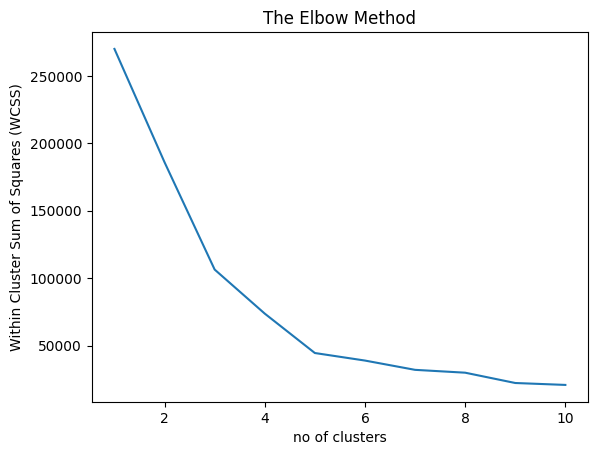

In [ ]:
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('no of clusters')
plt.ylabel('Within Cluster Sum of Squares (WCSS)')
plt.show()

In [ ]:
kmeansmodel = KMeans(n_clusters= 5, init='k-means++',
                     random_state=0)
newkmeansmodel= kmeansmodel.fit_predict(X)

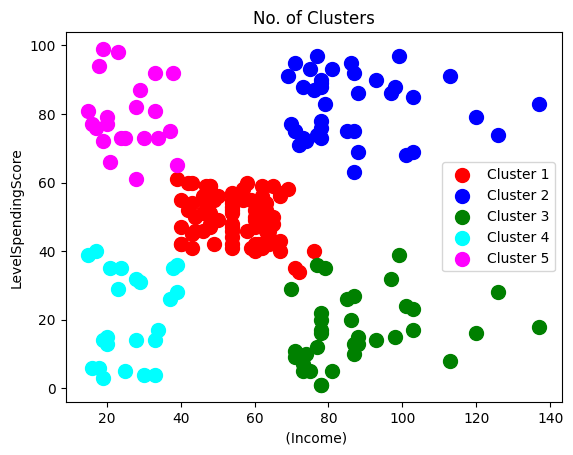

In [ ]:
plt.scatter(X[newkmeansmodel == 0, 0], X[newkmeansmodel == 0, 1],
            s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[newkmeansmodel == 1, 0], X[newkmeansmodel == 1, 1],
            s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[newkmeansmodel == 2, 0], X[newkmeansmodel == 2, 1],
            s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[newkmeansmodel == 3, 0], X[newkmeansmodel == 3, 1],
            s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[newkmeansmodel == 4, 0], X[newkmeansmodel == 4, 1],
            s = 100, c = 'magenta', label = 'Cluster 5')
plt.title('No. of Clusters')
plt.xlabel(' (Income)')
plt.ylabel('LevelSpendingScore')
plt.legend()
plt.show()

In [ ]:
#DBScan
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
dbscanmodel = DBSCAN(
     eps=0.5,
     min_samples=5
)
newdbscanmodel = dbscanmodel.fit_predict(X_scaled)
print(newdbscanmodel)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


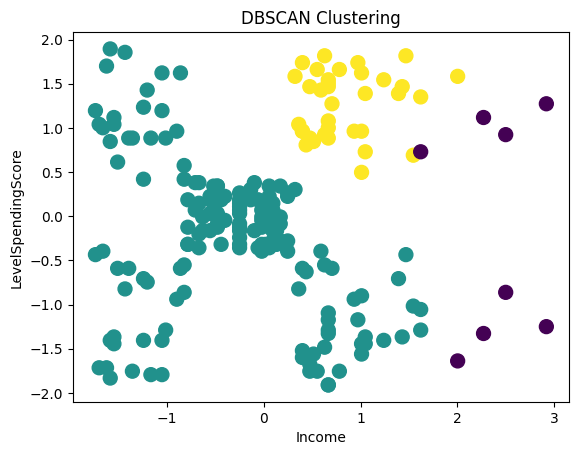

In [ ]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=newdbscanmodel,
    s=100
    )

plt.title('DBSCAN Clustering')
plt.xlabel('Income')
plt.ylabel('LevelSpendingScore')
plt.show()